## Дз 1. Анализ Фурье аналоговых (непрерывных) сигналов
**Вариант 2**

$$
x(t)=
\frac{a_2}{b_2 + \left|t - t_2\right|}
\exp\!\left(-c_2 \left|t - t_3\right|\right)
\,\mathrm{sinc}(d_2 t)
$$

Параметры:
```
a2 = -5
b2 =  2
t2 = -2
c2 =  0.4
t3 = -1
d2 =  9
```

## Генерация сигналов
#### 1. Проверка принадлежности сигнала к пространствам
---
$L^1(\mathbb{R})$:

**Функция принадлежит L1**, т.к. она везде интегрируема $\int_{-\infty}^{+\infty} |x(t)| \, dt < \infty$

**Проверка:**

В локальных точках:

С подставленными значениями параметров дробь всегда определена, кардинальный синус по модулю огрничен 1, экспонента тоже ограничена. Значит, на любом конечном интервале функция непрерывна и ограничена, поэтому интеграл по конечному отрезку тоже конечен.

При t -> inf:

Интеграл эквивалентен $\int_{1}^{\infty} \frac{e^{-0.4 t}}{t^2} \, dt$, который сходится (т.к. $\int_{1}^{\infty} e^{-0.4 t} \, dt$ точно конечен, а он больше предыдущего).

---

$L^2(\mathbb{R})$:

**Функция принадлежит L2**, т.к. она везде интегрируема $\int_{-\infty}^{+\infty} |x(t)|^2 \, dt < \infty$

**Проверка:**

Локально особенностей нет, т.к. в квадрате ничего не меняется, а на бескончности интеграл начинает просто быстрее сходиться.

---

$S$:

**Функция НЕ принадлжит S**, т.к. она не везде дифференцируема на R — в точке t = -2 производная не существует из-за модуля.

---

#### Свойства сигнала
Сигнал состоит из трёх компонент.

1. Он не периодический
2. Огрниченный (при t = 0, грубо, по модулю не превышает 1.5)
3. Экспоненциально убывающий (за счёт второй компоненты)
4. Смещён по времени (особые точки около t2 = -2 и t3 = -1)
5. Непрерывный, но не дифференцируемый (доказано выше)

#### Свойства преобразования Фурье
1. Амплитуда ограничена
2. Медленное убывание на высоких частотах (из-за первой компоненты)
3. Несимметрично из-за фазового сдвига (влияет второая компонента)
4. Есть осциляции из-за синка

#### 2. Построение графика сигнала

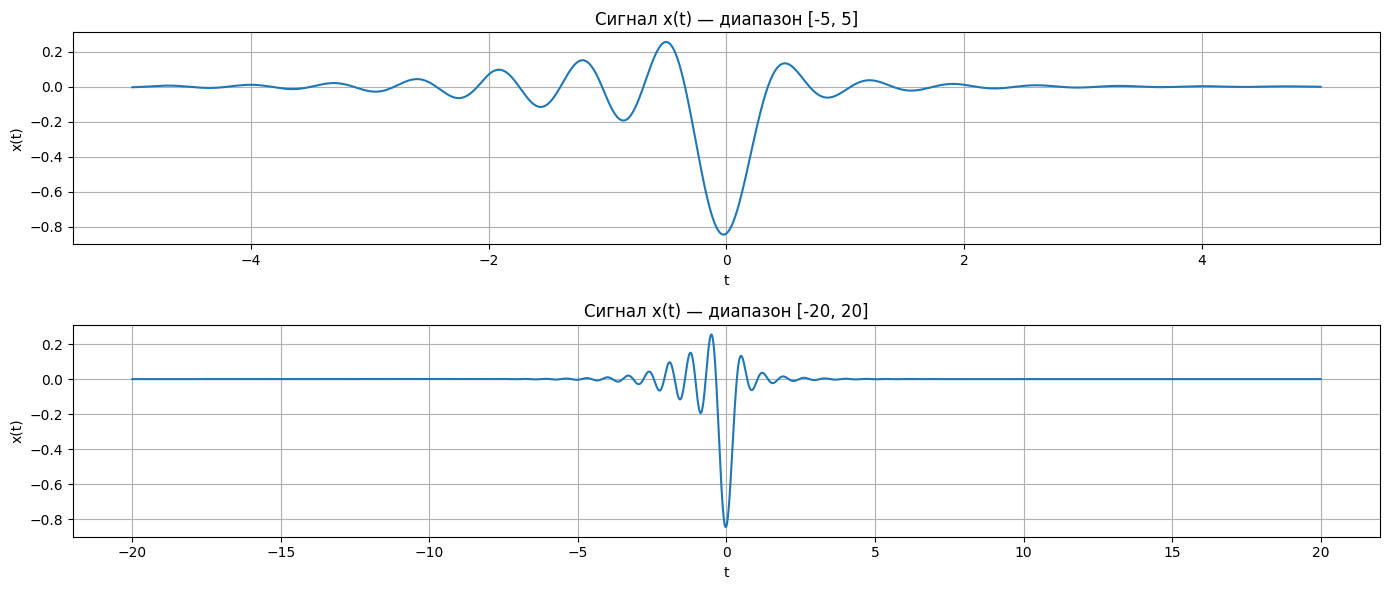

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала
a2 = -5
b2 = 2
t2 = -2
c2 = 0.4
t3 = -1
d2 = 9

# Функция сигнала
def x(t):
    return (a2 / (b2 + np.abs(t - t2))) * np.exp(-c2 * np.abs(t - t3)) * np.sinc(d2 * t / np.pi)

# Вариант 1
t_narrow_min = -5
t_narrow_max = 5
t1_range = np.linspace(t_narrow_min, t_narrow_max, 2000)
x1 = x(t1_range)

# Вариант 2
t_min = -20
t_max = 20
t2_range = np.linspace(t_min, t_max, 5000)
x2 = x(t2_range)

# Графики
plt.figure(figsize=(14, 6))

plt.subplot(2, 1, 1)
plt.plot(t1_range, x1)
plt.title(f"Сигнал x(t) — диапазон [{t_narrow_min}, {t_narrow_max}]")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t2_range, x2)
plt.title(f"Сигнал x(t) — диапазон [{t_min}, {t_max}]")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

Описанные раннее свйоства сигнала подтверждаются графиком.

## Спектральный анализ
#### 3. Прямое вычисление ПФ

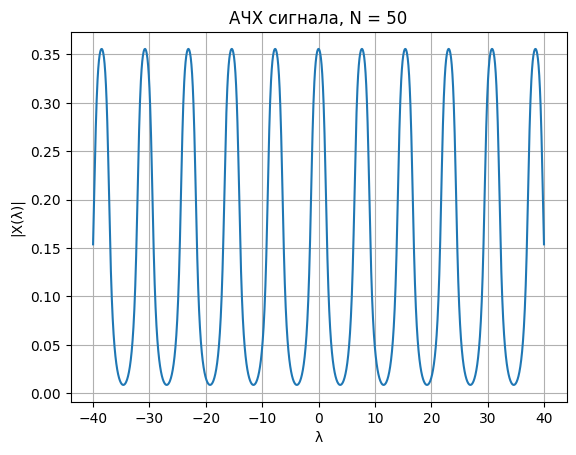

Δt = 0.816326530612244
Период ДПФ = 7.696902001295001
Время N=50: 0.007291555404663086 сек
Кол-во операций: ~2*M*N = 200000


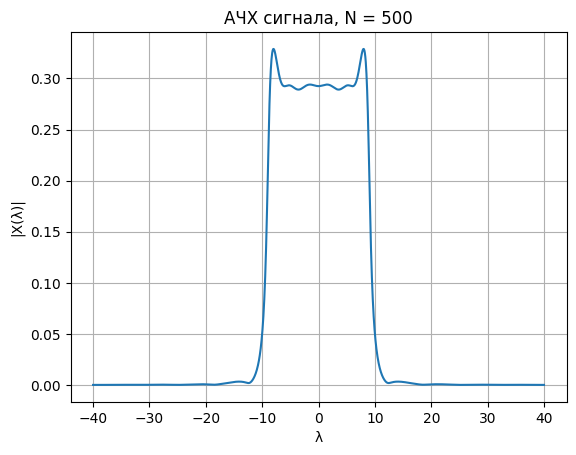

Δt = 0.08016032064128353
Период ДПФ = 78.3827367070644
Время N=500: 0.06089591979980469 сек
Кол-во операций: ~2*M*N = 2000000


In [69]:
import time

# Частотная ось
M = 2000
lambda_min = -40
lambda_max = 40
lambdas = np.linspace(lambda_min, lambda_max, M).reshape(M, 1)

def FT(N):
    # Сетка по времени
    t = np.linspace(t_min, t_max, N)
    dt = t[1] - t[0]

    t_row = t.reshape(1, -1)  # 1 × N
    x_col = x(t).reshape(-1, 1)  # N × 1

    # Матрица экспонент
    E = np.exp(-1j * lambdas @ t_row)  # M × N

    X = E @ x_col * dt  # M × 1

    return X.flatten(), dt

N1 = 50
start = time.time()
X1, dt1 = FT(N1)
end = time.time()

period1 = 2 * np.pi / dt1

plt.figure()
plt.plot(lambdas.flatten(), np.abs(X1))
plt.title("АЧХ сигнала, N = 50")
plt.xlabel("λ")
plt.ylabel("|X(λ)|")
plt.grid(True)
plt.show()

print("Δt =", dt1)
print("Период ДПФ =", period1)
print("Время N=50:", end - start, "сек")
print(f"Кол-во операций: ~2*M*N = {2 * M * N1}")

N2 = 500
start = time.time()
X2, dt2 = FT(N2)
end = time.time()

period2 = 2 * np.pi / dt2

plt.figure()
plt.plot(lambdas.flatten(), np.abs(X2))
plt.title("АЧХ сигнала, N = 500")
plt.xlabel("λ")
plt.ylabel("|X(λ)|")
plt.grid(True)
plt.show()

print("Δt =", dt2)
print("Период ДПФ =", period2)
print("Время N=500:", end - start, "сек")
print(f"Кол-во операций: ~2*M*N = {2 * M * N2}")

Видно, что при малом N шаг по времени большой, из-за чего аппроксимация получается грубой (амплитуда неточная, хвосты плохо различимы, ширину полосы трудно определить). Если же мы уменьшаем шаг по времени, аппроксимация к ПФ начинает больше отображать истинные характеристики сигнала, и уже станоится понятно, какие частоты есть в сигнале и с каком амплитудой (по модулю частота не превышает 9 рад/c с амплитудой около 0.35).

Видно, что время пропорционально произведению M на N.
> Это общее число элементов в матрице E, которая используется для вычисления ПФ. Каждая точка умножается на x(t) и суммируется (т.е. где-то 2 операции).

#### 4. Быстрое вычисление ПФ

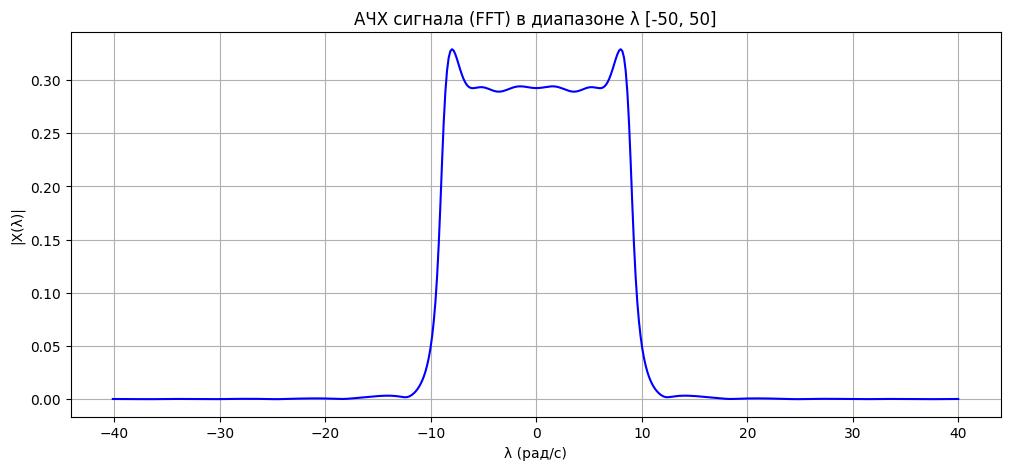

Период ДПФ = 80.26769229921786
Время работы FFT: 5.6743621826171875e-05 сек
Кол-во операций: N*log2(N) = 4608.0


In [70]:
def func(lambda_min = -50, lambda_max = 50):
    # Временная сетка
    N = 512
    t = np.linspace(t_min, t_max, N)
    dt = t[1] - t[0]

    xt = x(t)

    start = time.time()
    X_fft = np.fft.fft(xt)
    end = time.time()
    fft_time = end - start

    freqs = np.fft.fftfreq(N, d=dt) * 2 * np.pi  # все частоты в рад/с
    X_fft_shifted = np.fft.fftshift(X_fft)
    freqs_shifted = np.fft.fftshift(freqs)

    indices = np.where((freqs_shifted >= lambda_min) & (freqs_shifted <= lambda_max))
    lambdas_plot = freqs_shifted[indices]
    X_plot = X_fft_shifted[indices]

    # Амплитуда спектра
    X_mag = np.abs(X_plot) * dt  # масштабируем для прямого сравнения с интегралом

    plt.figure(figsize=(12, 5))
    plt.plot(lambdas_plot, X_mag, color="blue")
    plt.title(f"АЧХ сигнала (FFT) в диапазоне λ [{lambda_min}, {lambda_max}]")
    plt.xlabel("λ (рад/с)")
    plt.ylabel("|X(λ)|")
    plt.grid(True)
    plt.show()

    print("Период ДПФ =", 2 * np.pi / dt)
    print(f"Время работы FFT: {fft_time} сек")
    print(f"Кол-во операций: N*log2(N) = {N * np.log2(N)}")
func()

БПФ увеличило скорость работы преобразования сигнала в ~460 раз.

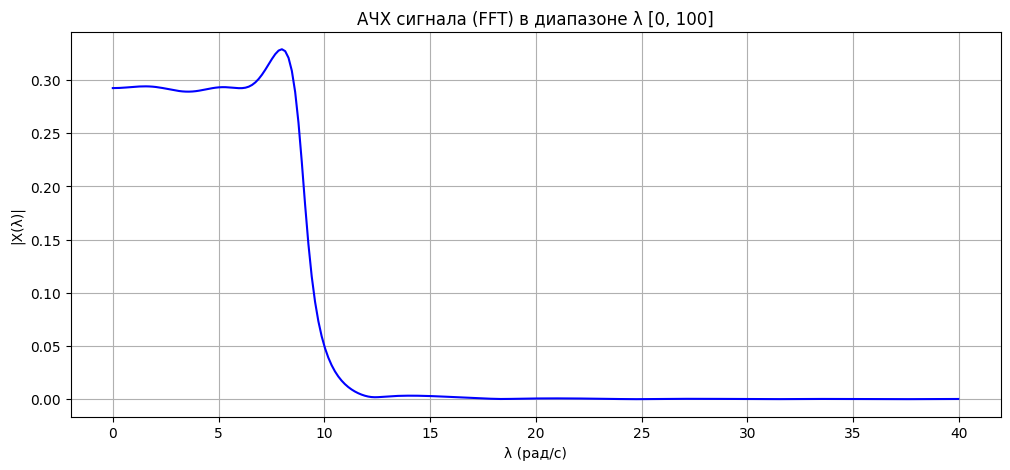

Период ДПФ = 80.26769229921786
Время работы FFT: 6.031990051269531e-05 сек
Кол-во операций: N*log2(N) = 4608.0


In [71]:
func(0, 100)

Чем ближе к максимальной лямбда, тем больше амплитуда приблажается к 0, что подтверждает гладкость сигнала и его принадлежность пространствам L1 и L2. Можно сказать, что сигнал физически  реализуемый, т.к. несёт конечную энергию